# FastF1 data exploration

Phase 1. Goal: for every section we want on the
dashboard (weather / circuit / standings prediction / tyre strategy / safety car /
fun facts), find out which FastF1 object holds the data, what the columns are,
how expensive it is to fetch, and when in the race weekend it becomes available.

Everything here uses the 2025 season as the reference season.

| Section | Question |
|---|---|
| 1 | Season schedule — what a race weekend looks like, and when each session runs |
| 2 | Session results — grid, finish, status, points (the prediction labels) |
| 3 | Weather — per-session samples, season-wide summary |
| 4 | Circuit info — corners, rotation, track map |
| 5 | Laps & stints — tyre compounds, stint lengths, degradation |
| 6 | Track status & race control — safety car, VSC, red flags |
| 7 | Telemetry — speed / throttle / DRS, and what it costs to load |
| 8 | Ergast (jolpica) — standings and pit stops that FastF1 timing doesn't expose |
| 9 | Availability map — which section can refresh on Thu / Fri / Sat / Sun |
| 10 | Season results — race, sprint, qualifying and sprint qualifying for a whole season |
| 11 | Session summaries — per-driver and per-session features for every session of a weekend |
| 12 | Long runs & tyre degradation — Friday race pace |
| 13 | Weekend feature table — stage-safe features joined per driver |
| 14 | Session timeline — minute-by-minute weather, flags and race control |

Sections 10–14 use the reusable functions in `src/data_explore.py`.

## 0 · Setup

Cache lives in `data/fastf1_cache/` and is gitignored. First fetch of a session is slow
(network); every later load is local.

In [ ]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "nb":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import fastf1
import fastf1.plotting as f1plt
from fastf1.ergast import Ergast

from src.config import SEASON, enable_cache
import src.data_explore as data_explore
import src.session as session_utils

enable_cache()

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
FastF1 3.8.3 | cache -> data/fastf1_cache


In [87]:
# One reference round used throughout the notebook. Change this to look at another race.
RACE_ROUND = 14
SEASON = 2021

## 1 · Season schedule

In [88]:
schedule = fastf1.get_event_schedule(SEASON, include_testing=False)

print(f"{SEASON} season: {len(schedule)} rounds")
print(f"Event formats: {schedule['EventFormat'].value_counts().to_dict()}")
print(f"Columns: {schedule.columns.tolist()}")

schedule[["RoundNumber", "EventName", "Country", "Location", "EventDate", "EventFormat"]]

2021 season: 22 rounds
Event formats: {'conventional': 19, 'sprint': 3}
Columns: ['RoundNumber', 'Country', 'Location', 'OfficialEventName', 'EventDate', 'EventName', 'EventFormat', 'Session1', 'Session1Date', 'Session1DateUtc', 'Session2', 'Session2Date', 'Session2DateUtc', 'Session3', 'Session3Date', 'Session3DateUtc', 'Session4', 'Session4Date', 'Session4DateUtc', 'Session5', 'Session5Date', 'Session5DateUtc', 'F1ApiSupport']


,RoundNumber,EventName,Country,Location,EventDate,EventFormat
1,1,Bahrain Grand Prix,Bahrain,Sakhir,2021-03-28,conventional
2,2,Emilia Romagna Grand Prix,Italy,Imola,2021-04-18,conventional
3,3,Portuguese Grand Prix,Portugal,Portimão,2021-05-02,conventional
4,4,Spanish Grand Prix,Spain,Barcelona,2021-05-09,conventional
5,5,Monaco Grand Prix,Monaco,Monte Carlo,2021-05-23,conventional
6,6,Azerbaijan Grand Prix,Azerbaijan,Baku,2021-06-06,conventional
7,7,French Grand Prix,France,Le Castellet,2021-06-20,conventional
8,8,Styrian Grand Prix,Austria,Spielberg,2021-06-27,conventional
9,9,Austrian Grand Prix,Austria,Spielberg,2021-07-04,conventional
10,10,British Grand Prix,Great Britain,Silverstone,2021-07-18,sprint


In [89]:
# Each event carries 5 named sessions with a local and a UTC datetime.
# The session names differ between conventional and sprint weekends -- this is
# exactly what drives the Thu/Fri/Sat/Sun refresh schedule.
for fmt in schedule["EventFormat"].unique():
    example = schedule.loc[schedule["EventFormat"] == fmt].iloc[0]
    print(f"\n{fmt.upper()} -- e.g. {example['EventName']}")
    for i in range(1, 6):
        name = example[f"Session{i}"]
        start = example[f"Session{i}DateUtc"]
        print(f"  Session{i}: {name:<22} {start} UTC")


CONVENTIONAL -- e.g. Bahrain Grand Prix
  Session1: Practice 1             2021-03-26 11:30:00 UTC
  Session2: Practice 2             2021-03-26 15:00:00 UTC
  Session3: Practice 3             2021-03-27 12:00:00 UTC
  Session4: Qualifying             2021-03-27 15:00:00 UTC
  Session5: Race                   2021-03-28 15:00:00 UTC

SPRINT -- e.g. British Grand Prix
  Session1: Practice 1             2021-07-16 13:30:00 UTC
  Session2: Qualifying             2021-07-16 17:00:00 UTC
  Session3: Practice 2             2021-07-17 11:00:00 UTC
  Session4: Sprint                 2021-07-17 15:30:00 UTC
  Session5: Race                   2021-07-18 14:00:00 UTC


In [90]:
# Split into completed vs upcoming. Only completed rounds have timing data.
today = pd.Timestamp.now(tz="UTC").tz_localize(None)

completed = schedule.loc[schedule["EventDate"] < today].copy()
upcoming = schedule.loc[schedule["EventDate"] >= today].copy()

print(f"{len(completed)} completed, {len(upcoming)} upcoming (as of {today.date()})")
if len(upcoming):
    nxt = upcoming.iloc[0]
    print(f"Next up: R{nxt['RoundNumber']} {nxt['EventName']} on {nxt['EventDate'].date()}")

22 completed, 0 upcoming (as of 2026-10-02)


## 2 · Session results

`Session.results` is a DataFrame that always has the same columns regardless of session
type — irrelevant ones are just empty. This is the label source for the ranking model,
and `GridPosition` is the single strongest feature the demo notebook was missing.

In [91]:
session = fastf1.get_session(SEASON, RACE_ROUND, "R")
session.load(telemetry=False)

print(session)
print(f"Total laps: {session.total_laps} | drivers: {len(session.drivers)}")
print(f"Result columns: {session.results.columns.tolist()}")

core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

2021 Season Round 14: Italian Grand Prix - Race
Total laps: 53 | drivers: 20
Result columns: ['DriverNumber', 'BroadcastName', 'Abbreviation', 'DriverId', 'TeamName', 'TeamColor', 'TeamId', 'FirstName', 'LastName', 'FullName', 'HeadshotUrl', 'CountryCode', 'Position', 'ClassifiedPosition', 'GridPosition', 'Q1', 'Q2', 'Q3', 'Time', 'Status', 'Points', 'Laps']


In [92]:
result_cols = ["Abbreviation", "FullName", "TeamName", "GridPosition", "Position",
               "ClassifiedPosition", "Status", "Points", "Laps", "Time"]

session.results[result_cols]

,Abbreviation,FullName,TeamName,GridPosition,Position,ClassifiedPosition,Status,Points,Laps,Time
3,RIC,Daniel Ricciardo,McLaren,2.0,1.0,1,Finished,26.0,53.0,0 days 01:21:54.365000
4,NOR,Lando Norris,McLaren,3.0,2.0,2,Finished,18.0,53.0,0 days 00:00:01.747000
77,BOT,Valtteri Bottas,Mercedes,19.0,3.0,3,Finished,15.0,53.0,0 days 00:00:04.921000
16,LEC,Charles Leclerc,Ferrari,5.0,4.0,4,Finished,12.0,53.0,0 days 00:00:07.309000
11,PER,Sergio Perez,Red Bull Racing,8.0,5.0,5,Finished,10.0,53.0,0 days 00:00:08.723000
55,SAI,Carlos Sainz,Ferrari,6.0,6.0,6,Finished,8.0,53.0,0 days 00:00:10.535000
18,STR,Lance Stroll,Aston Martin,9.0,7.0,7,Finished,6.0,53.0,0 days 00:00:15.804000
14,ALO,Fernando Alonso,Alpine,10.0,8.0,8,Finished,4.0,53.0,0 days 00:00:17.201000
63,RUS,George Russell,Williams,14.0,9.0,9,Finished,2.0,53.0,0 days 00:00:19.742000
31,OCO,Esteban Ocon,Alpine,12.0,10.0,10,Finished,1.0,53.0,0 days 00:00:20.868000


In [93]:
# ClassifiedPosition is the *official* classification and carries the DNF reasons:
# integer = classified, "R" retired, "D" disqualified, "E" excluded, "N" not classified.
# Status says why. Both matter for the SC/incident model and for "did they finish" features.
print(session.results["Status"].value_counts().to_dict())

dnf = session.results.loc[~session.results["ClassifiedPosition"].str.isdigit()]
dnf[["Abbreviation", "TeamName", "ClassifiedPosition", "Status", "Laps"]]

{'Finished': 15, 'Collision': 2, 'Power Unit': 1, 'Suspension': 1, 'Brakes': 1}


,Abbreviation,TeamName,ClassifiedPosition,Status,Laps
9,MAZ,Haas F1 Team,R,Power Unit,41.0
44,HAM,Mercedes,R,Collision,25.0
33,VER,Red Bull Racing,R,Collision,25.0
10,GAS,AlphaTauri,R,Suspension,3.0
22,TSU,AlphaTauri,W,Brakes,0.0


In [94]:
# Qualifying carries Q1/Q2/Q3 times -- available Saturday, i.e. before the race prediction
# has to be published. Loading results only (no laps/weather/messages) is fast.
quali = fastf1.get_session(SEASON, RACE_ROUND, "Q")
quali.load(laps=True, telemetry=False, weather=False, messages=False)

quali.results[["Abbreviation", "TeamName", "Position", "Q1", "Q2", "Q3"]]

core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 

,Abbreviation,TeamName,Position,Q1,Q2,Q3
77,BOT,Mercedes,1.0,0 days 00:01:20.685000,0 days 00:01:20.032000,0 days 00:01:19.555000
44,HAM,Mercedes,2.0,0 days 00:01:20.543000,0 days 00:01:19.936000,0 days 00:01:19.651000
33,VER,Red Bull Racing,3.0,0 days 00:01:21.035000,0 days 00:01:20.229000,0 days 00:01:19.966000
4,NOR,McLaren,4.0,0 days 00:01:20.916000,0 days 00:01:20.059000,0 days 00:01:19.989000
3,RIC,McLaren,5.0,0 days 00:01:21.292000,0 days 00:01:20.435000,0 days 00:01:19.995000
10,GAS,AlphaTauri,6.0,0 days 00:01:21.440000,0 days 00:01:20.556000,0 days 00:01:20.260000
55,SAI,Ferrari,7.0,0 days 00:01:21.118000,0 days 00:01:20.750000,0 days 00:01:20.462000
16,LEC,Ferrari,8.0,0 days 00:01:21.219000,0 days 00:01:20.767000,0 days 00:01:20.510000
11,PER,Red Bull Racing,9.0,0 days 00:01:21.308000,0 days 00:01:20.882000,0 days 00:01:20.611000
99,GIO,Alfa Romeo Racing,10.0,0 days 00:01:21.197000,0 days 00:01:20.726000,0 days 00:01:20.808000


In [36]:
# Grid vs finish for one race: how much of the result is decided on Saturday?
grid_vs_finish = session.results[["Abbreviation", "GridPosition", "Position"]].dropna()
corr = grid_vs_finish["GridPosition"].corr(grid_vs_finish["Position"], method="spearman")

print(f"Spearman(grid, finish) = {corr:.3f}")
grid_vs_finish.assign(gained=lambda d: d["GridPosition"] - d["Position"]).sort_values("gained", ascending=False)

Spearman(grid, finish) = 0.489


,Abbreviation,GridPosition,Position,gained
12,ANT,16.0,4.0,12.0
27,HUL,17.0,7.0,10.0
18,STR,13.0,6.0,7.0
31,OCO,19.0,13.0,6.0
87,BEA,20.0,14.0,6.0
30,LAW,18.0,15.0,3.0
63,RUS,4.0,3.0,1.0
23,ALB,6.0,5.0,1.0
1,VER,3.0,2.0,1.0
4,NOR,1.0,1.0,0.0


## 3 · Weather

`Session.weather_data` is one sample per minute for the whole session:
`Time, AirTemp, Humidity, Pressure, Rainfall, TrackTemp, WindDirection, WindSpeed`.

Note this is *observed* weather — FastF1 has no forecast. For the Thursday/Friday
"race week weather" panel we will need an external forecast API and can only use
FastF1 weather as the historical prior (how often is this circuit wet in September?).

→ feeds **比赛周天气**.

In [37]:
weather = session.weather_data

print(f"{len(weather)} samples, one per minute")
print(f"Columns: {weather.columns.tolist()}")

weather.head()

178 samples, one per minute
Columns: ['Time', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed']


,Time,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed
0,0 days 00:00:07.776000,15.8,91.0,1009.2,True,18.8,211,2.6
1,0 days 00:01:07.777000,15.7,92.0,1009.2,True,18.8,273,2.6
2,0 days 00:02:07.763000,15.7,92.0,1009.0,True,18.8,271,2.2
3,0 days 00:03:07.777000,15.7,90.0,1009.1,True,18.8,261,5.3
4,0 days 00:04:07.778000,15.7,90.0,1009.4,True,18.8,246,5.6


In [38]:
weather.describe()

,Time,AirTemp,Humidity,Pressure,TrackTemp,WindDirection,WindSpeed
count,178,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,0 days 01:28:38.324617977,15.707865,78.421348,1009.901685,18.942135,242.286517,3.475281
std,0 days 00:51:32.060679469,0.375740,6.506580,0.444994,0.276315,48.757696,1.242267
min,0 days 00:00:07.776000,15.100000,68.000000,1009.000000,18.300000,0.000000,0.700000
25%,0 days 00:44:22.973750,15.400000,74.000000,1009.500000,18.700000,238.250000,2.600000
50%,0 days 01:28:38.324000,15.700000,76.000000,1010.000000,19.000000,257.000000,3.500000
75%,0 days 02:12:53.618250,16.000000,86.000000,1010.300000,19.200000,268.000000,4.300000
max,0 days 02:57:09.022000,16.600000,92.000000,1010.700000,19.400000,301.000000,6.900000


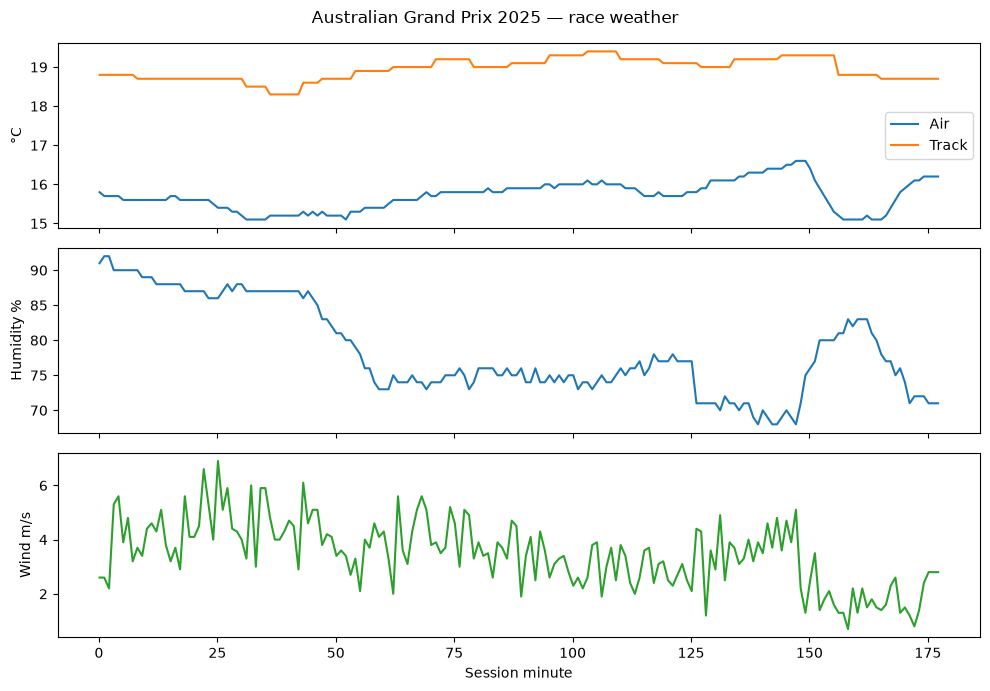

In [39]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
minutes = weather["Time"].dt.total_seconds() / 60

axes[0].plot(minutes, weather["AirTemp"], label="Air")
axes[0].plot(minutes, weather["TrackTemp"], label="Track")
axes[0].set_ylabel("°C"); axes[0].legend()

axes[1].plot(minutes, weather["Humidity"], color="tab:blue")
axes[1].set_ylabel("Humidity %")

axes[2].plot(minutes, weather["WindSpeed"], color="tab:green")
axes[2].set_ylabel("Wind m/s"); axes[2].set_xlabel("Session minute")

fig.suptitle(f"{session.event['EventName']} {SEASON} — race weather")
plt.tight_layout()
plt.show()

In [40]:
# Season-wide weather. Weather-only loads skip laps/telemetry/messages so this is
# the cheap way to scan a whole season -- still expect a few minutes on a cold cache.
def race_weather(year, rnd):
    s = fastf1.get_session(year, rnd, "R")
    s.load(laps=False, telemetry=False, weather=True, messages=False)
    w = s.weather_data
    return {
        "round": rnd,
        "event": s.event["EventName"],
        "air_temp": w["AirTemp"].mean(),
        "track_temp_max": w["TrackTemp"].max(),
        "humidity": w["Humidity"].mean(),
        "wind_speed": w["WindSpeed"].mean(),
        "rain_pct": 100 * w["Rainfall"].mean(),
    }

weather_season = pd.DataFrame([race_weather(SEASON, r) for r in completed["RoundNumber"]])
weather_season.round(1)

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '63', '12', '23', '18', '27', '16', '81', '44', '10', '22', '31', '87', '30', '5', '14', '55', '7', '6']
core           INFO 	Loading data for Chinese Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '63', '1', '31', '12', '23', '87', '18', '55', '6', '30', '7', '5', '27', '22', '14', '16', '44', '10']
core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached dat

,round,event,air_temp,track_temp_max,humidity,wind_speed,rain_pct
0,1,Australian Grand Prix,15.7,19.4,78.4,3.5,32.6
1,2,Chinese Grand Prix,27.2,43.0,18.2,2.2,0.0
2,3,Japanese Grand Prix,14.4,23.0,76.4,1.2,0.0
3,4,Bahrain Grand Prix,27.1,34.8,45.3,2.1,0.0
4,5,Saudi Arabian Grand Prix,29.5,39.4,62.7,1.0,0.0
5,6,Miami Grand Prix,26.6,45.2,63.0,1.0,3.4
6,7,Emilia Romagna Grand Prix,24.0,45.9,38.3,3.2,0.0
7,8,Monaco Grand Prix,22.2,45.2,52.5,1.0,0.0
8,9,Spanish Grand Prix,29.1,50.4,54.6,1.6,0.0
9,10,Canadian Grand Prix,24.0,50.4,28.0,1.0,0.6


In [41]:
# Which 2025 races were actually wet?
wet = weather_season.loc[weather_season["rain_pct"] > 0].sort_values("rain_pct", ascending=False)
print(f"{len(wet)} of {len(weather_season)} races saw rainfall")
wet[["round", "event", "rain_pct", "air_temp", "track_temp_max"]].round(1)

6 of 24 races saw rainfall


,round,event,rain_pct,air_temp,track_temp_max
12,13,Belgian Grand Prix,45.7,17.0,27.6
0,1,Australian Grand Prix,32.6,15.7,19.4
11,12,British Grand Prix,18.1,17.9,29.6
17,18,Singapore Grand Prix,3.7,29.1,38.8
5,6,Miami Grand Prix,3.4,26.6,45.2
9,10,Canadian Grand Prix,0.6,24.0,50.4


## 4 · Circuit info

`Session.get_circuit_info()` returns corners, marshal lights and marshal sectors as
DataFrames (`X, Y, Number, Letter, Angle, Distance`) plus a `rotation` angle for drawing
the map the right way up. The data comes from MultiViewer — hand-made, good enough for
visuals, not for physics.

`Distance` is only filled once telemetry is loaded.

→ feeds **赛道信息**.

In [42]:
circuit = session.get_circuit_info()

print(f"{len(circuit.corners)} corners | {len(circuit.marshal_lights)} marshal lights "
      f"| {len(circuit.marshal_sectors)} marshal sectors | rotation {circuit.rotation}°")

circuit.corners.head(10)

data        WARNING 	Failed to generate marker distance information: telemetry data has not been loaded


14 corners | 20 marshal lights | 20 marshal sectors | rotation 44.0°


,X,Y,Number,Letter,Angle,Distance
0,-3650.594482,1193.784180,1,,-176.632730,NaN
1,-3555.053223,1992.750244,2,,-1.517007,NaN
2,-7194.970215,7101.942383,3,,162.258315,NaN
3,-5878.734375,7709.864746,4,,-23.426263,NaN
4,-5870.662598,9676.805664,5,,159.215959,NaN
5,-2280.641357,11861.559570,6,,96.736266,NaN
6,-1296.382446,11398.008789,7,,-104.065903,NaN
7,502.412537,10576.311523,8,,39.145642,NaN
8,2838.843750,798.959839,9,,-101.197334,NaN
9,3973.896484,855.019897,10,,73.476771,NaN


In [43]:
# The track map needs positional telemetry. This is the one expensive load in the
# notebook -- tens of MB per session on a cold cache, instant afterwards.
session_tel = fastf1.get_session(SEASON, RACE_ROUND, "R")
session_tel.load(telemetry=True, weather=False, messages=False)

fastest = session_tel.laps.pick_fastest()
pos = fastest.get_pos_data()

print(f"Fastest lap: {fastest['Driver']} {fastest['LapTime']} on lap {fastest['LapNumber']:.0f}")
print(f"Position samples: {len(pos)} | columns: {pos.columns.tolist()}")

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
core        WARNING 	Driver 4 completed the race distance 00:00.022000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INF

Fastest lap: NOR 0 days 00:01:22.167000 on lap 43
Position samples: 322 | columns: ['Date', 'Status', 'X', 'Y', 'Z', 'Source', 'Time', 'SessionTime']


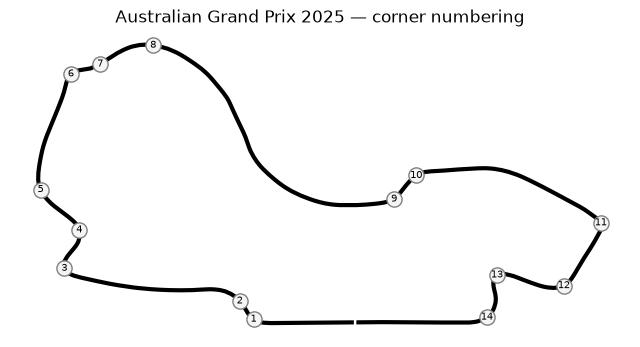

In [44]:
# Rotate the track into its broadcast orientation and label the corners.
angle = circuit.rotation / 180 * np.pi
rot = np.array([[np.cos(angle), np.sin(angle)], [-np.sin(angle), np.cos(angle)]])

track = np.column_stack([pos["X"], pos["Y"]]) @ rot
corners = np.column_stack([circuit.corners["X"], circuit.corners["Y"]]) @ rot

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(track[:, 0], track[:, 1], color="black", lw=3)
for (x, y), (_, corner) in zip(corners, circuit.corners.iterrows()):
    ax.scatter(x, y, s=120, color="whitesmoke", edgecolor="grey", zorder=3)
    ax.text(x, y, f"{corner['Number']}{corner['Letter']}", ha="center", va="center", fontsize=7, zorder=4)

ax.set_aspect("equal")
ax.axis("off")
ax.set_title(f"{session_tel.event['EventName']} {SEASON} — corner numbering")
plt.show()

## 5 · Laps & tyre strategy

`Session.laps` is the workhorse: one row per driver per lap, with `Compound`, `TyreLife`,
`FreshTyre`, `Stint`, `PitInTime`/`PitOutTime`, sector times, speed traps and
`TrackStatus`. `IsAccurate` flags laps that FastF1 considers clean enough to compare.

→ feeds **最佳轮胎策略**.

In [45]:
laps = session.laps

print(f"{len(laps)} laps x {len(laps.columns)} columns")
print(f"Columns: {laps.columns.tolist()}")
print(f"Compounds used: {laps['Compound'].value_counts().to_dict()}")
print(f"Accurate laps: {laps['IsAccurate'].sum()} / {len(laps)}")

laps.head()

927 laps x 31 columns
Columns: ['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']
Compounds used: {'INTERMEDIATE': 750, 'HARD': 92, 'MEDIUM': 85}
Accurate laps: 568 / 927


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:13:00.002000,VER,1,0 days 00:01:59.392000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:20.705000,0 days 00:00:55.250000,NaT,0 days 01:12:04.853000,0 days 01:13:00.058000,249.0,292.0,247.0,215.0,False,INTERMEDIATE,1.0,True,Red Bull Racing,0 days 01:11:00.355000,NaT,124,2.0,False,,False,False
1,0 days 01:15:49.358000,VER,1,NaT,2.0,1.0,NaT,0 days 01:15:38.205000,0 days 00:00:58.141000,0 days 00:00:37.976000,0 days 00:01:13.205000,0 days 01:13:58.233000,0 days 01:14:36.257000,0 days 01:15:49.446000,66.0,222.0,NaN,210.0,False,INTERMEDIATE,2.0,True,Red Bull Racing,0 days 01:13:00.002000,NaT,4,2.0,False,,False,False
2,0 days 01:18:31.526000,VER,1,NaT,3.0,2.0,0 days 01:15:51.658000,0 days 01:18:20.223000,0 days 00:00:56.230000,0 days 00:00:33.683000,0 days 00:01:12.232000,0 days 01:16:45.667000,0 days 01:17:19.489000,0 days 01:18:31.643000,78.0,203.0,NaN,180.0,False,INTERMEDIATE,3.0,False,Red Bull Racing,0 days 01:15:49.358000,NaT,4,2.0,False,,False,False
3,0 days 01:21:07.226000,VER,1,NaT,4.0,3.0,0 days 01:18:34.029000,0 days 01:20:56.543000,0 days 00:00:54.351000,0 days 00:00:32.712000,0 days 00:01:08.712000,0 days 01:19:26.041000,0 days 01:19:58.680000,0 days 01:21:07.378000,103.0,240.0,NaN,187.0,False,INTERMEDIATE,4.0,False,Red Bull Racing,0 days 01:18:31.526000,NaT,4,2.0,False,,False,False
4,0 days 01:23:30.835000,VER,1,0 days 00:02:23.609000,5.0,4.0,0 days 01:21:09.534000,NaT,0 days 00:00:53.513000,0 days 00:00:32.627000,0 days 00:00:57.469000,0 days 01:22:00.795000,0 days 01:22:33.422000,0 days 01:23:30.891000,79.0,130.0,237.0,194.0,False,INTERMEDIATE,5.0,False,Red Bull Racing,0 days 01:21:07.226000,NaT,4,2.0,False,,False,False


In [46]:
# Stint table: one row per driver per stint. This *is* the strategy chart.
stints = (laps.groupby(["Driver", "Stint", "Compound"], as_index=False)
              .agg(start_lap=("LapNumber", "min"),
                   end_lap=("LapNumber", "max"),
                   tyre_laps=("LapNumber", "count"),
                   median_pace=("LapTime", "median")))

stints.sort_values(["Driver", "Stint"]).head(20)

,Driver,Stint,Compound,start_lap,end_lap,tyre_laps,median_pace
0,ALB,1.0,INTERMEDIATE,1.0,2.0,2,-53376 days +00:07:27.670112256
1,ALB,2.0,INTERMEDIATE,3.0,3.0,1,NaT
2,ALB,3.0,INTERMEDIATE,4.0,4.0,1,NaT
3,ALB,4.0,INTERMEDIATE,5.0,33.0,29,0 days 00:01:32.717000
4,ALB,5.0,MEDIUM,34.0,44.0,11,0 days 00:02:07.143000
5,ALB,6.0,INTERMEDIATE,45.0,57.0,13,0 days 00:01:34.996000
6,ALO,1.0,INTERMEDIATE,1.0,2.0,2,-53376 days +00:07:30.161612288
7,ALO,2.0,INTERMEDIATE,3.0,3.0,1,NaT
8,ALO,3.0,INTERMEDIATE,4.0,4.0,1,NaT
9,ALO,4.0,INTERMEDIATE,5.0,33.0,29,0 days 00:01:32.545000


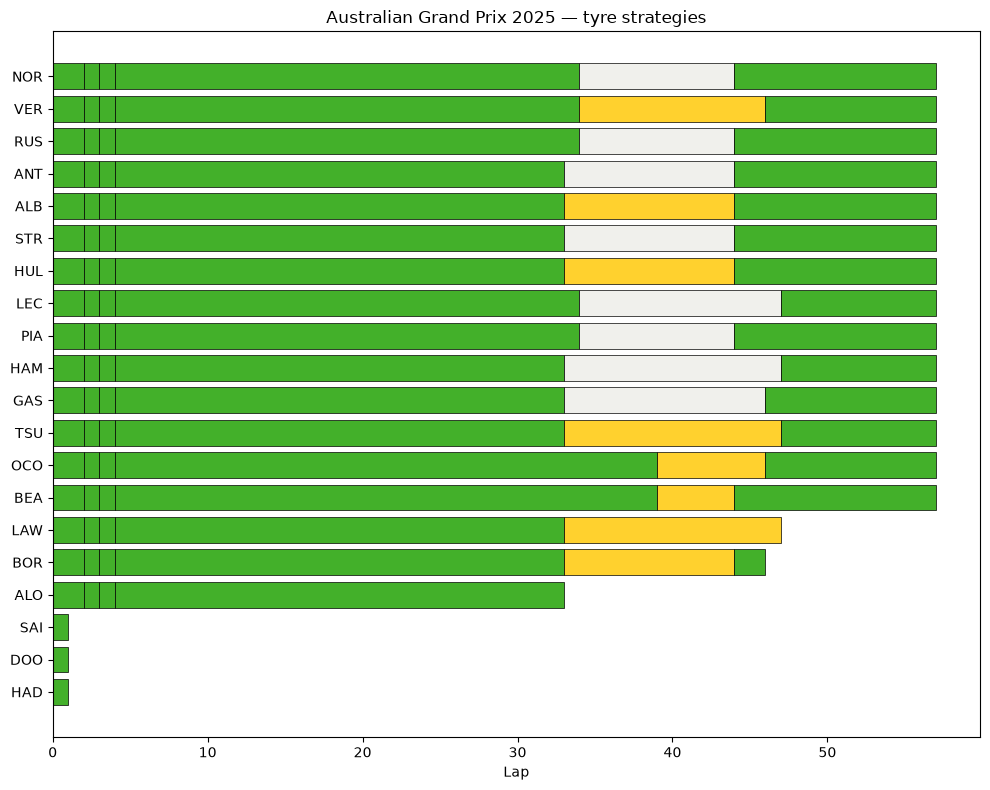

In [47]:
# Strategy chart -- horizontal stint bars per driver, coloured by compound.
order = session.results["Abbreviation"].dropna().tolist()

fig, ax = plt.subplots(figsize=(10, 8))
for driver in order:
    offset = 0
    for _, stint in stints.loc[stints["Driver"] == driver].sort_values("Stint").iterrows():
        ax.barh(driver, stint["tyre_laps"], left=offset,
                color=f1plt.get_compound_color(stint["Compound"], session=session),
                edgecolor="black", linewidth=0.5)
        offset += stint["tyre_laps"]

ax.invert_yaxis()
ax.set_xlabel("Lap")
ax.set_title(f"{session.event['EventName']} {SEASON} — tyre strategies")
plt.tight_layout()
plt.show()

In [48]:
# Pace by compound, restricted to quick laps (within 107% of the session best).
by_compound = (laps.pick_quicklaps()
                   .groupby("Compound")["LapTime"]
                   .agg(laps="count", median="median", best="min"))

by_compound

,laps,median,best
Compound,,,
HARD,15,0 days 00:01:25.065000,0 days 00:01:22.167000
INTERMEDIATE,6,0 days 00:01:27.595000,0 days 00:01:27.126000
MEDIUM,17,0 days 00:01:25.317000,0 days 00:01:22.970000


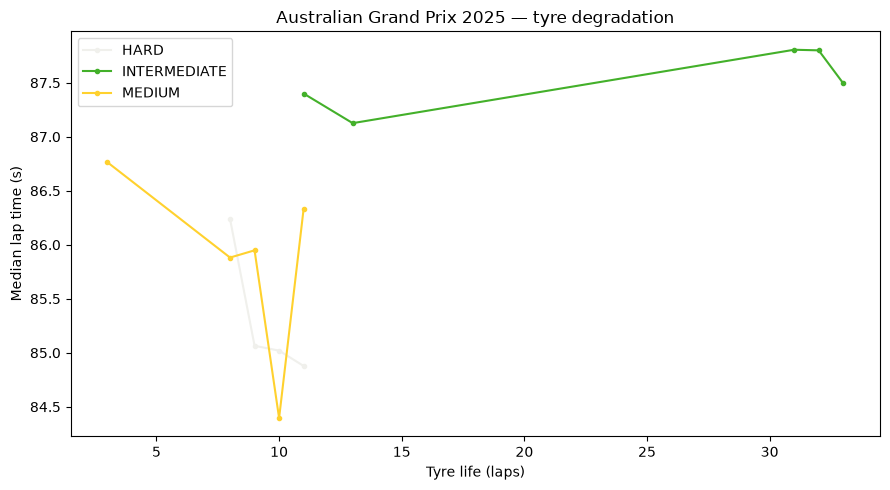

In [49]:
# Degradation: median quick-lap time against tyre age, per compound.
# This curve is what an "optimal strategy" recommendation has to be built on.
deg = (laps.pick_quicklaps()
           .assign(lap_seconds=lambda d: d["LapTime"].dt.total_seconds())
           .groupby(["Compound", "TyreLife"], as_index=False)["lap_seconds"]
           .median())

fig, ax = plt.subplots(figsize=(9, 5))
for compound, group in deg.groupby("Compound"):
    ax.plot(group["TyreLife"], group["lap_seconds"], marker="o", ms=3, label=compound,
            color=f1plt.get_compound_color(compound, session=session))

ax.set_xlabel("Tyre life (laps)")
ax.set_ylabel("Median lap time (s)")
ax.set_title(f"{session.event['EventName']} {SEASON} — tyre degradation")
ax.legend()
plt.tight_layout()
plt.show()

In [50]:
# Pit stops as seen by the timing data: PitInTime sits on the in-lap, PitOutTime on the
# NEXT row (the out-lap), so pit-lane time needs a shift. Counting PitInTime can over-count:
# some races show spurious stops late on, so cross-check with Stint changes and Ergast.
box_laps = laps.loc[laps["PitInTime"].notna(), ["Driver", "LapNumber", "Compound", "TyreLife"]]

print(f"{len(box_laps)} pit stops, {box_laps.groupby('Driver').size().mean():.1f} per driver")
box_laps.groupby("LapNumber").size().rename("stops").to_frame().T

82 pit stops, 4.8 per driver


LapNumber,2.0,3.0,4.0,33.0,34.0,39.0,44.0,46.0,47.0
stops,17,17,17,9,5,2,9,3,3


## 6 · Track status & race control

Two sources for incidents:

- `Session.track_status` — one row per status change, `Status` is a single digit:
  `1` clear, `2` yellow, `4` safety car, `5` red flag, `6` VSC deployed, `7` VSC ending.
- `Session.race_control_messages` — the actual messages, with
  `Time, Category, Message, Status, Flag, Scope, Sector, RacingNumber, Lap`.

Each lap also carries a `TrackStatus` string concatenating every status active during
that lap (so `"14"` means the lap started clear and went to safety car).

→ feeds **安全车 / 红旗预测**.

In [51]:
STATUS_LABELS = {"1": "AllClear", "2": "Yellow", "4": "SafetyCar",
                 "5": "RedFlag", "6": "VSCDeployed", "7": "VSCEnding"}

track_status = session.track_status.copy()
track_status["Label"] = track_status["Status"].map(STATUS_LABELS)

print(f"{len(track_status)} status changes")
track_status

20 status changes


,Time,Status,Message,Label
0,0 days 00:00:24.491000,1,AllClear,AllClear
1,0 days 00:17:40.825000,2,Yellow,Yellow
2,0 days 00:17:45.814000,1,AllClear,AllClear
3,0 days 00:34:20.843000,2,Yellow,Yellow
4,0 days 00:35:54.306000,1,AllClear,AllClear
5,0 days 00:41:37.243000,2,Yellow,Yellow
6,0 days 00:42:24.684000,1,AllClear,AllClear
7,0 days 00:53:36.416000,2,Yellow,Yellow
8,0 days 00:57:54.535000,1,AllClear,AllClear
9,0 days 01:12:05.120000,2,Yellow,Yellow


In [52]:
# Which laps ran under which status.
for code, label in [("4", "Safety car"), ("6", "VSC"), ("5", "Red flag"), ("2", "Yellow")]:
    affected = sorted(laps.loc[laps["TrackStatus"].str.contains(code, na=False), "LapNumber"].unique())
    print(f"{label:<12} {len(affected):>3} laps  {affected}")

Safety car    22 laps  [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(33.0), np.float64(34.0), np.float64(35.0), np.float64(36.0), np.float64(37.0), np.float64(38.0), np.float64(39.0), np.float64(40.0), np.float64(41.0), np.float64(46.0), np.float64(47.0), np.float64(48.0), np.float64(49.0), np.float64(50.0), np.float64(51.0)]
VSC            0 laps  []
Red flag       0 laps  []
Yellow         8 laps  [np.float64(1.0), np.float64(32.0), np.float64(33.0), np.float64(34.0), np.float64(44.0), np.float64(45.0), np.float64(46.0), np.float64(47.0)]


In [53]:
rcm = session.race_control_messages

print(f"{len(rcm)} messages | categories: {rcm['Category'].value_counts().to_dict()}")
rcm.loc[rcm["Category"] == "Flag", ["Time", "Lap", "Flag", "Scope", "Sector", "Message"]].head(20)

113 messages | categories: {'Flag': 57, 'Other': 45, 'SafetyCar': 7, 'Drs': 4}


,Time,Lap,Flag,Scope,Sector,Message
2,2025-03-16 03:20:01,1,GREEN,Track,NaN,GREEN LIGHT - PIT EXIT OPEN
3,2025-03-16 03:25:03,1,YELLOW,Sector,17.0,YELLOW IN TRACK SECTOR 17
4,2025-03-16 03:25:08,1,CLEAR,Sector,17.0,CLEAR IN TRACK SECTOR 17
6,2025-03-16 03:41:43,1,DOUBLE YELLOW,Sector,10.0,DOUBLE YELLOW IN TRACK SECTOR 10
7,2025-03-16 03:42:22,1,YELLOW,Sector,9.0,YELLOW IN TRACK SECTOR 9
8,2025-03-16 03:43:16,1,CLEAR,Sector,10.0,CLEAR IN TRACK SECTOR 10
9,2025-03-16 03:43:17,1,CLEAR,Sector,9.0,CLEAR IN TRACK SECTOR 9
11,2025-03-16 03:49:00,1,DOUBLE YELLOW,Sector,3.0,DOUBLE YELLOW IN TRACK SECTOR 3
12,2025-03-16 03:49:47,1,CLEAR,Sector,3.0,CLEAR IN TRACK SECTOR 3
13,2025-03-16 04:00:59,1,DOUBLE YELLOW,Sector,2.0,DOUBLE YELLOW IN TRACK SECTOR 2


In [54]:
# Incident messages are free-text -- useful for the fun-fact section and as weak labels.
incident_words = "INCIDENT|PENALTY|INVESTIGATION|DELETED|CAR \\d+"
rcm.loc[rcm["Message"].str.contains(incident_words, case=False, na=False),
        ["Lap", "Category", "Message"]].head(20)

,Lap,Category,Message
30,8,Other,INCIDENT INVOLVING CAR 14 (ALO) NOTED - SAFETY...
31,9,Other,INCIDENT INVOLVING CAR 22 (TSU) NOTED - SAFETY...
32,9,Other,FIA STEWARDS: INCIDENT INVOLVING CAR 14 (ALO) ...
33,10,Other,FIA STEWARDS: INCIDENT INVOLVING CAR 22 (TSU) ...
35,17,Other,CAR 12 (ANT) TIME 1:37.326 DELETED - TRACK LIM...
40,18,Other,INCIDENT INVOLVING CAR 23 (ALB) NOTED - SAFETY...
41,18,Other,INCIDENT INVOLVING CAR 44 (HAM) NOTED - SAFETY...
46,19,Other,FIA STEWARDS: INCIDENT INVOLVING CAR 23 (ALB) ...
49,19,Other,FIA STEWARDS: INCIDENT INVOLVING CAR 44 (HAM) ...
50,20,Other,FIA STEWARDS: INCIDENT INVOLVING CAR 14 (ALO) ...


In [55]:
# Season-wide incident counts -- the label set for a safety car / red flag model.
# Needs laps + messages, so this is the slowest scan in the notebook.
def race_incidents(year, rnd):
    s = fastf1.get_session(year, rnd, "R")
    s.load(laps=True, telemetry=False, weather=False, messages=True)
    ts = s.track_status
    return {
        "round": rnd,
        "event": s.event["EventName"],
        "total_laps": s.total_laps,
        "sc_periods": int((ts["Status"] == "4").sum()),
        "vsc_periods": int((ts["Status"] == "6").sum()),
        "red_flags": int((ts["Status"] == "5").sum()),
        "yellows": int((ts["Status"] == "2").sum()),
        "dnfs": int((~s.results["ClassifiedPosition"].str.isdigit()).sum()),
    }

incidents = pd.DataFrame([race_incidents(SEASON, r) for r in completed["RoundNumber"]])
incidents

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
core        WARNING 	Driver 4 completed the race distance 00:00.022000 before the recorded end of the session.
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4

,round,event,total_laps,sc_periods,vsc_periods,red_flags,yellows,dnfs
0,1,Australian Grand Prix,57,3,0,0,8,6
1,2,Chinese Grand Prix,56,0,0,0,7,4
2,3,Japanese Grand Prix,53,0,0,0,0,0
3,4,Bahrain Grand Prix,57,1,0,0,0,2
4,5,Saudi Arabian Grand Prix,50,1,0,0,1,2
5,6,Miami Grand Prix,57,0,3,0,7,4
6,7,Emilia Romagna Grand Prix,63,1,1,0,2,2
7,8,Monaco Grand Prix,78,0,1,0,4,2
8,9,Spanish Grand Prix,66,1,0,0,5,2
9,10,Canadian Grand Prix,70,1,0,0,4,2


In [56]:
# Base rates -- the number any SC prediction has to beat.
print(f"Races with >=1 safety car: {(incidents['sc_periods'] > 0).mean():.0%}")
print(f"Races with >=1 VSC:        {(incidents['vsc_periods'] > 0).mean():.0%}")
print(f"Races with a red flag:     {(incidents['red_flags'] > 0).mean():.0%}")
print(f"Mean DNFs per race:        {incidents['dnfs'].mean():.1f}")

incidents.sort_values("sc_periods", ascending=False).head(10)[
    ["round", "event", "sc_periods", "vsc_periods", "red_flags", "dnfs"]]

Races with >=1 safety car: 54%
Races with >=1 VSC:        38%
Races with a red flag:     4%
Mean DNFs per race:        2.3


,round,event,sc_periods,vsc_periods,red_flags,dnfs
0,1,Australian Grand Prix,3,0,0,6
14,15,Dutch Grand Prix,3,1,0,2
11,12,British Grand Prix,2,2,0,5
9,10,Canadian Grand Prix,1,0,0,2
22,23,Qatar Grand Prix,1,0,0,2
20,21,São Paulo Grand Prix,1,1,0,3
16,17,Azerbaijan Grand Prix,1,0,0,1
10,11,Austrian Grand Prix,1,0,0,4
12,13,Belgian Grand Prix,1,0,1,0
8,9,Spanish Grand Prix,1,0,0,2


## 7 · Telemetry

`Session.car_data` and `Session.pos_data` are dicts keyed by driver number, ~4 Hz for the
whole session. Rich, but heavy — this is the reason `telemetry=False` is the default in
every other cell here. Reuses `session_tel` loaded in section 4.

→ feeds **fun facts** (top speed, full-throttle share, DRS usage).

In [57]:
car = session_tel.car_data
pos = session_tel.pos_data

sample_driver = session_tel.results.index[0]
print(f"Drivers with telemetry: {len(car)}")
print(f"car_data columns: {car[sample_driver].columns.tolist()}")
print(f"pos_data columns: {pos[sample_driver].columns.tolist()}")
print(f"Samples for driver {sample_driver}: {len(car[sample_driver]):,}")

Drivers with telemetry: 20
car_data columns: ['Date', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source', 'Time', 'SessionTime']
pos_data columns: ['Date', 'Status', 'X', 'Y', 'Z', 'Source', 'Time', 'SessionTime']
Samples for driver 4: 38,421


In [58]:
# Fun-fact material: top speed and full-throttle share on each driver's fastest lap.
# DRS no longer exists from 2026 (active aero); check what the DRS channel carries first.
rows = []
for number in session_tel.drivers:
    driver_laps = session_tel.laps.pick_drivers(number)
    fastest_lap = driver_laps.pick_fastest()
    if fastest_lap is None or pd.isna(fastest_lap["LapTime"]):
        continue
    tel = fastest_lap.get_car_data()
    rows.append({
        "driver": session_tel.get_driver(number)["Abbreviation"],
        "top_speed": tel["Speed"].max(),
        "full_throttle_pct": 100 * (tel["Throttle"] >= 99).mean(),
        "brake_pct": 100 * tel["Brake"].mean(),
        "drs_pct": 100 * tel["DRS"].isin([10, 12, 14]).mean(),
    })

pd.DataFrame(rows).sort_values("top_speed", ascending=False).round(1)

,driver,top_speed,full_throttle_pct,brake_pct,drs_pct
3,ANT,332.0,54.3,16.4,20.5
4,ALB,329.0,50.2,23.0,18.0
11,TSU,327.0,57.8,19.0,12.4
5,STR,326.0,57.4,20.4,13.8
14,LAW,322.0,61.8,15.9,20.7
9,HAM,322.0,57.0,23.7,21.2
10,GAS,312.0,57.9,17.0,0.0
7,LEC,311.0,56.1,18.7,7.2
6,HUL,307.0,58.1,19.0,0.0
2,RUS,306.0,59.2,17.6,0.0


## 8 · Ergast / jolpica

`fastf1.ergast.Ergast` now points at the jolpica mirror (`api.jolpi.ca`) since ergast.com
was retired. It gives two things FastF1's own timing data does not expose neatly:
**championship standings** and **pit stop durations**.

It is rate limited, so batch and cache anything the dashboard needs.

→ feeds **排名预测** (standings context) and **fun facts** (fastest stop).

In [59]:
ergast = Ergast(result_type="pandas", auto_cast=True)

standings = ergast.get_driver_standings(season=SEASON).content[0]
print(f"Columns: {standings.columns.tolist()}")

standings[["position", "driverCode", "givenName", "familyName", "constructorNames", "points", "wins"]]

Columns: ['position', 'positionText', 'points', 'wins', 'driverId', 'driverNumber', 'driverCode', 'driverUrl', 'givenName', 'familyName', 'dateOfBirth', 'driverNationality', 'constructorIds', 'constructorUrls', 'constructorNames', 'constructorNationalities']


,position,driverCode,givenName,familyName,constructorNames,points,wins
0,1,NOR,Lando,Norris,[McLaren],423.0,7
1,2,VER,Max,Verstappen,[Red Bull],421.0,8
2,3,PIA,Oscar,Piastri,[McLaren],410.0,7
3,4,RUS,George,Russell,[Mercedes],319.0,2
4,5,LEC,Charles,Leclerc,[Ferrari],242.0,0
5,6,HAM,Lewis,Hamilton,[Ferrari],156.0,0
6,7,ANT,Andrea Kimi,Antonelli,[Mercedes],150.0,0
7,8,ALB,Alexander,Albon,[Williams],73.0,0
8,9,SAI,Carlos,Sainz,[Williams],64.0,0
9,10,ALO,Fernando,Alonso,[Aston Martin],56.0,0


In [60]:
constructors = ergast.get_constructor_standings(season=SEASON).content[0]
constructors[["position", "constructorName", "points", "wins"]]

,position,constructorName,points,wins
0,1,McLaren,833.0,14
1,2,Mercedes,469.0,2
2,3,Red Bull,451.0,8
3,4,Ferrari,398.0,0
4,5,Williams,137.0,0
5,6,RB F1 Team,92.0,0
6,7,Aston Martin,89.0,0
7,8,Haas F1 Team,79.0,0
8,9,Sauber,70.0,0
9,10,Alpine F1 Team,22.0,0


In [61]:
# Pit stop durations. Ergast's duration is the pit-lane time (entry to exit), not the
# stationary time -- no public source has that.
# Default page limit is 30 -- a race has ~40 stops, so raise it.
pit_stops = ergast.get_pit_stops(season=SEASON, round=RACE_ROUND, limit=200).content[0]

print(f"{len(pit_stops)} stops | columns: {pit_stops.columns.tolist()}")
pit_stops.sort_values("duration").head(10)

82 stops | columns: ['driverId', 'stop', 'lap', 'time', 'duration']


,driverId,stop,lap,time,duration
34,norris,3,4,15:28:16,0 days 00:00:12.804000
36,piastri,3,4,15:28:20,0 days 00:00:12.816000
17,norris,2,3,15:25:40,0 days 00:00:12.910000
35,max_verstappen,3,4,15:28:18,0 days 00:00:12.938000
2,piastri,1,2,15:23:02,0 days 00:00:13.078000
0,norris,1,2,15:22:58,0 days 00:00:13.341000
1,max_verstappen,1,2,15:23:00,0 days 00:00:13.416000
39,tsunoda,3,4,15:28:28,0 days 00:00:13.605000
3,russell,1,2,15:23:03,0 days 00:00:13.672000
37,russell,3,4,15:28:22,0 days 00:00:13.696000


In [62]:
# Race results via Ergast for comparison: same race, driverId/constructorId keys that
# join against historical seasons. The demo notebook built its whole feature set on this.
ergast_results = ergast.get_race_results(season=SEASON, round=RACE_ROUND).content[0]
print(f"Columns: {ergast_results.columns.tolist()}")

ergast_results[["position", "driverId", "constructorId", "grid", "laps", "points", "status"]]

Columns: ['number', 'position', 'positionText', 'points', 'grid', 'laps', 'status', 'driverId', 'driverNumber', 'driverCode', 'driverUrl', 'givenName', 'familyName', 'dateOfBirth', 'driverNationality', 'constructorId', 'constructorUrl', 'constructorName', 'constructorNationality', 'totalRaceTimeMillis', 'totalRaceTime', 'fastestLapRank', 'fastestLapNumber', 'fastestLapTime']


,position,driverId,constructorId,grid,laps,points,status
0,1,norris,mclaren,1,57,25.0,Finished
1,2,max_verstappen,red_bull,3,57,18.0,Finished
2,3,russell,mercedes,4,57,15.0,Finished
3,4,antonelli,mercedes,16,57,12.0,Finished
4,5,albon,williams,6,57,10.0,Finished
5,6,stroll,aston_martin,13,57,8.0,Finished
6,7,hulkenberg,sauber,17,57,6.0,Finished
7,8,leclerc,ferrari,7,57,4.0,Finished
8,9,piastri,mclaren,2,57,2.0,Finished
9,10,hamilton,ferrari,8,57,1.0,Finished


## 9 · Availability map

The dashboard refreshes Thursday → Sunday. Not every section has data on every day, and
getting this wrong means publishing a stale or empty panel. This table is the contract
the Phase 2 pipeline has to honour.

In [63]:
availability = pd.DataFrame([
    # section,              source,                          thu,   fri,   sat,   sun
    ("Race week header",    "get_event_schedule",            True,  True,  True,  True),
    ("Circuit info",        "Session.get_circuit_info",      True,  True,  True,  True),
    ("Weather (forecast)",  "external forecast API",         True,  True,  True,  True),
    ("Weather (observed)",  "Session.weather_data",          False, True,  True,  True),
    ("Practice pace",       "Session.laps (FP1-FP3)",        False, True,  True,  True),
    ("Grid",                "Session('Q').results",          False, False, True,  True),
    ("Ranking prediction",  "model on schedule+quali",       True,  True,  True,  True),
    ("Tyre strategy",       "Session.laps Compound/Stint",   False, True,  True,  True),
    ("Safety car forecast", "history + circuit priors",      True,  True,  True,  True),
    ("Fun facts",           "telemetry + Ergast + history",  True,  True,  True,  True),
], columns=["section", "source", "thu", "fri", "sat", "sun"])

availability

,section,source,thu,fri,sat,sun
0,Race week header,get_event_schedule,True,True,True,True
1,Circuit info,Session.get_circuit_info,True,True,True,True
2,Weather (forecast),external forecast API,True,True,True,True
3,Weather (observed),Session.weather_data,False,True,True,True
4,Practice pace,Session.laps (FP1-FP3),False,True,True,True
5,Grid,Session('Q').results,False,False,True,True
6,Ranking prediction,model on schedule+quali,True,True,True,True
7,Tyre strategy,Session.laps Compound/Stint,False,True,True,True
8,Safety car forecast,history + circuit priors,True,True,True,True
9,Fun facts,telemetry + Ergast + history,True,True,True,True


In [64]:
# Cost of each source, so the Phase 2 pipeline knows what it can afford per refresh.
cost = pd.DataFrame([
    ("get_event_schedule",       "1 request",        "seconds"),
    ("Session.results only",     "load(laps=False, telemetry=False, weather=False, messages=False)", "seconds"),
    ("Session weather only",     "load(laps=False, telemetry=False, weather=True, messages=False)",  "~10s cold"),
    ("Session laps + messages",  "load(telemetry=False)",  "~30s cold"),
    ("Session full telemetry",   "load(telemetry=True)",   "minutes, tens of MB"),
    ("Ergast standings",         "1 request, rate limited", "seconds"),
], columns=["source", "call", "cost"])

cost

,source,call,cost
0,get_event_schedule,1 request,seconds
1,Session.results only,"load(laps=False, telemetry=False, weather=Fals...",seconds
2,Session weather only,"load(laps=False, telemetry=False, weather=True...",~10s cold
3,Session laps + messages,load(telemetry=False),~30s cold
4,Session full telemetry,load(telemetry=True),"minutes, tens of MB"
5,Ergast standings,"1 request, rate limited",seconds


### Open questions for Phase 2

- **Weather forecast** has no FastF1 source. Need an external API (Open-Meteo is free and
  needs no key) keyed on the circuit lat/lon — which Ergast `get_circuits` provides.
- **Tyre allocation** (which compounds Pirelli brings to each round) is not in FastF1 at
  all. Either scrape it or hardcode per round.
- **Overtakes** have no direct field. Closest proxy is lap-by-lap position change from
  `Session.laps["Position"]`, which counts pit cycles as overtakes — needs filtering.
- **Sprint weekends** shift the session layout, so anything keyed on "Session4 == Qualifying"
  will break. Use `Event.get_qualifying()` / `get_race()` instead of session numbers.
- **Cold cache on a fresh server**: a full 2025 scan with telemetry is large. Decide what the
  deployed job caches vs. recomputes.

## 10 · Season results (all classified sessions)

Sections 2 and 8 fetch one round at a time. `data_explore.get_season_results(year, kind)`
fetches a whole season for any classified session type and hides the jolpica paging
(pages are cut by row count, so one race can straddle two pages).

- `race`, `sprint`, `qualifying` come from Ergast.
- `sprint_qualifying` is **not in Ergast**. It comes from each FastF1 SQ session, which
  classifies drivers by SQ1/SQ2/SQ3 elimination. That needs `messages=True`.

Every table carries `season`, `round`, `session` and the Ergast `driverId`, the join key
the pipeline uses everywhere.

→ labels for **排名预测** and the qualifying model.

In [65]:
season_results = {kind: data_explore.get_season_results(SEASON, kind)[0]
                  for kind in ["qualifying", "sprint_qualifying", "sprint", "race"]}

# Entrants per round is not always 20: 2025 Spain had 19, 2026 has 22
for kind, df in season_results.items():
    per_round = df.groupby("round").size()
    print(f"{kind:<18} {len(df):>4} rows | {df['round'].nunique():>2} rounds | "
          f"entrants per round {sorted(per_round.unique())}")

core           INFO 	Loading data for Chinese Grand Prix - Sprint Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
core        WARNING 	Sprint Qualifying is not supported by Ergast! Limited results are calculated from timing data.
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['44', '1', '81', '16', '63', '4', '12', '22', '23', '18', '14', '87', '55', '5', '6', '7', '10', '31', '27', '30']
core           INFO 	Loading data for Miami Grand Prix - Sprint Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req         

qualifying          479 rows | 24 rounds | entrants per round [np.int64(19), np.int64(20)]
sprint_qualifying   120 rows |  6 rounds | entrants per round [np.int64(20)]
sprint              120 rows |  6 rounds | entrants per round [np.int64(20)]
race                479 rows | 24 rounds | entrants per round [np.int64(19), np.int64(20)]


In [66]:
# Grid is not qualifying position: penalties push a driver back (grid > quali position)
# and a pit-lane start shows as grid 0. Everyone behind a penalised driver moves up one.
race_res = season_results["race"]
quali_res = season_results["qualifying"][["round", "driverId", "position"]]

grid = race_res.merge(quali_res.rename(columns={"position": "quali_position"}), on=["round", "driverId"])
penalised = grid.loc[(grid["grid"] > grid["quali_position"]) | (grid["grid"] == 0)]

print(f"{len(penalised)} of {len(grid)} starts were penalised or from the pit lane")
penalised[["round", "driverCode", "quali_position", "grid", "position", "status"]].head(15)

29 of 478 starts were penalised or from the pit lane


,round,driverCode,quali_position,grid,position,status
53,3,SAI,12,15,14,Finished
61,4,RUS,2,3,2,Finished
70,4,ANT,4,5,11,Finished
112,6,GAS,18,20,13,Finished
135,7,COL,15,16,16,Finished
136,7,BEA,16,19,17,Finished
144,8,HAM,4,7,5,Finished
151,8,BEA,17,20,12,Lapped
190,10,TSU,11,18,12,Lapped
194,10,HAD,9,12,16,Lapped


## 11 · Session summaries

`data_explore.summarize_session(session)` turns one loaded session into two tables:

- **by driver**: best lap, sectors, ideal lap, top speed, laps per compound, clean-lap pace
  and consistency, gaps in % and ranks (comparable across circuits), and race control
  counts (track limits, incidents, penalties, blue flags).
- **session row**: weather over the running window only, yellow / SC / VSC / red counts and
  minutes, race control totals and the announced rain risk.

It works for every session type. Session-specific features (quali position, grid, stints)
are added on top. The session needs laps, weather and messages, but not telemetry.

→ feeds every prediction section; the session row feeds **安全车 / 红旗预测**.

In [ ]:
# FastF1 session names -> the session ids used for stages in docs/artifact-schema.md
weekend = session_utils.load_weekend(SEASON, RACE_ROUND)
summaries = {sid: data_explore.summarize_session(s) for sid, s in weekend.items()}
print(f"{weekend['R'].event['EventName']}: {list(weekend)}")

core           INFO 	Loading data for Australian Grand Prix - Practice 1 [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '5', '6', '7', '10', '12', '14', '16', '18', '22', '23', '27', '30', '31', '44', '55', '63', '81', '87']
core           INFO 	Loading data for Australian Grand Prix - Practice 2 [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Us

Australian Grand Prix: ['FP1', 'FP2', 'FP3', 'Q', 'R']


In [68]:
# Session level: one row per session of the weekend
session_rows = pd.concat([row for _, row in summaries.values()]).set_index("session")
session_rows[["duration_min", "track_temp_mean", "rain_frac", "wet_laps_frac", "yellow_n",
              "sc_n", "sc_min", "vsc_n", "red_n", "red_min", "penalties_n", "track_limits_n"]].round(2)

,duration_min,track_temp_mean,rain_frac,wet_laps_frac,yellow_n,sc_n,sc_min,vsc_n,red_n,red_min,penalties_n,track_limits_n
session,,,,,,,,,,,,
Practice 1,60.00,42.40,0.00,0.00,2,0,0.00,0,2,16.21,0,0
Practice 2,60.00,40.85,0.00,0.00,0,0,0.00,0,0,0.00,0,0
Practice 3,60.00,41.23,0.00,0.00,2,0,0.00,0,1,7.06,0,0
Qualifying,60.00,40.63,0.00,0.00,4,0,0.00,0,0,0.00,0,11
Race,102.11,19.11,0.32,0.81,4,3,43.13,0,0,0.00,2,8


In [69]:
# Driver level, first practice: pace, mileage and tyre usage
fp1_by_driver = summaries["FP1"][0].sort_values("best_lap_rank")
fp1_by_driver[["Driver", "team", "best_lap", "best_lap_gap_pct", "ideal_lap_gap_pct", "team_gap_pct",
               "top_speed_st", "laps_driven", "clean_laps", "clean_lap_std", "best_lap_at_min",
               "track_limits_n"]].round(3)

,Driver,team,best_lap,best_lap_gap_pct,ideal_lap_gap_pct,team_gap_pct,top_speed_st,laps_driven,clean_laps,clean_lap_std,best_lap_at_min,track_limits_n
12,NOR,McLaren,77.252,0.000,0.000,0.000,325.0,21,6,1.680,57.511,0
16,SAI,Williams,77.401,0.193,0.219,0.000,321.0,25,5,1.150,35.656,0
11,LEC,Ferrari,77.461,0.271,0.276,0.000,321.0,21,6,0.925,35.814,0
14,PIA,McLaren,77.670,0.541,0.567,0.541,324.0,20,6,1.532,50.918,0
19,VER,Red Bull Racing,77.696,0.575,0.476,0.000,326.0,21,4,1.822,27.851,0
0,ALB,Williams,77.713,0.597,0.623,0.403,322.0,18,4,1.792,57.629,0
15,RUS,Mercedes,77.716,0.601,0.553,0.000,322.0,26,8,2.047,29.396,0
1,ALO,Aston Martin,77.736,0.627,0.637,0.000,324.0,23,7,1.295,58.040,0
7,HAD,Racing Bulls,77.847,0.770,0.796,0.000,323.0,25,8,1.392,58.262,0
17,STR,Aston Martin,78.057,1.042,0.908,0.413,322.0,20,6,0.732,53.870,0


## 12 · Long runs & tyre degradation

Friday long runs are the best pre-race signal for race pace, and the only one for
degradation. For each stint: keep clean laps (`pick_wo_box`, green flag, accurate, not
deleted), drop cool-down laps (>3% slower than the stint median), keep stints of 8+
laps, then take the median lap and a robust slope (Theil-Sen) of lap time against tyre life.

Two things make the raw slope misleading, so compare drivers **relative to the field**:

- Fuel burn makes the car roughly 0.03–0.06 s/lap faster, which offsets degradation.
  Slopes near or below zero are normal on low-degradation tracks.
- Fuel loads differ by team and are not published.

On a sprint weekend FP1 is the only practice, so these features are weaker or missing.

→ feeds **最佳轮胎策略** and race-pace features for **排名预测**.

In [70]:
from scipy.stats import theilslopes

MIN_STINT_LAPS = 8


def long_runs(session, min_laps=MIN_STINT_LAPS):
    """one row per clean stint of min_laps+ laps: median pace and degradation slope"""
    clean = session.laps.pick_wo_box().pick_track_status("1").pick_accurate().pick_not_deleted()
    clean = clean.assign(lap_s=clean["LapTime"].dt.total_seconds())

    # cool-down laps stay green and accurate, so filter them against the stint median
    stint_median = clean.groupby(["Driver", "Stint"])["lap_s"].transform("median")
    clean = clean[clean["lap_s"] <= stint_median * 1.03]

    rows = []
    for (driver, stint), g in clean.groupby(["Driver", "Stint"]):
        if len(g) < min_laps:
            continue
        rows.append({
            "Driver": driver,
            "Stint": int(stint),
            "Compound": g["Compound"].iloc[0],
            "laps": len(g),
            "median_lap_s": g["lap_s"].median(),
            "deg_s_per_lap": theilslopes(g["lap_s"], g["TyreLife"])[0],
        })
    return pd.DataFrame(rows)


long_run_session = weekend["FP2"] if "FP2" in weekend else weekend["FP1"]
runs = long_runs(long_run_session)

# relative to the field on the same compound
by_compound = runs.groupby("Compound")
runs["pace_gap_pct"] = (runs["median_lap_s"] / by_compound["median_lap_s"].transform("min") - 1) * 100
runs["deg_vs_field"] = runs["deg_s_per_lap"] - by_compound["deg_s_per_lap"].transform("median")

print(f"{long_run_session.name}: {len(runs)} long runs from {runs['Driver'].nunique()} drivers | "
      f"{runs['Compound'].value_counts().to_dict()}")
runs.sort_values(["Compound", "pace_gap_pct"]).round(3)

Practice 2: 17 long runs from 17 drivers | {'MEDIUM': 14, 'HARD': 2, 'SOFT': 1}


,Driver,Stint,Compound,laps,median_lap_s,deg_s_per_lap,pace_gap_pct,deg_vs_field
13,RUS,4,HARD,11,81.876,-0.039,0.000,0.023
1,ANT,5,HARD,11,82.156,-0.085,0.342,-0.023
10,NOR,3,MEDIUM,9,81.916,-0.111,0.000,-0.092
6,HAM,5,MEDIUM,12,82.137,-0.145,0.270,-0.126
12,PIA,3,MEDIUM,9,82.146,-0.031,0.281,-0.012
9,LEC,5,MEDIUM,12,82.312,-0.151,0.483,-0.132
14,SAI,5,MEDIUM,10,82.338,-0.007,0.515,0.012
7,HUL,4,MEDIUM,8,82.462,0.114,0.667,0.133
16,TSU,4,MEDIUM,15,82.563,0.014,0.790,0.033
3,DOO,3,MEDIUM,12,82.600,0.018,0.836,0.037


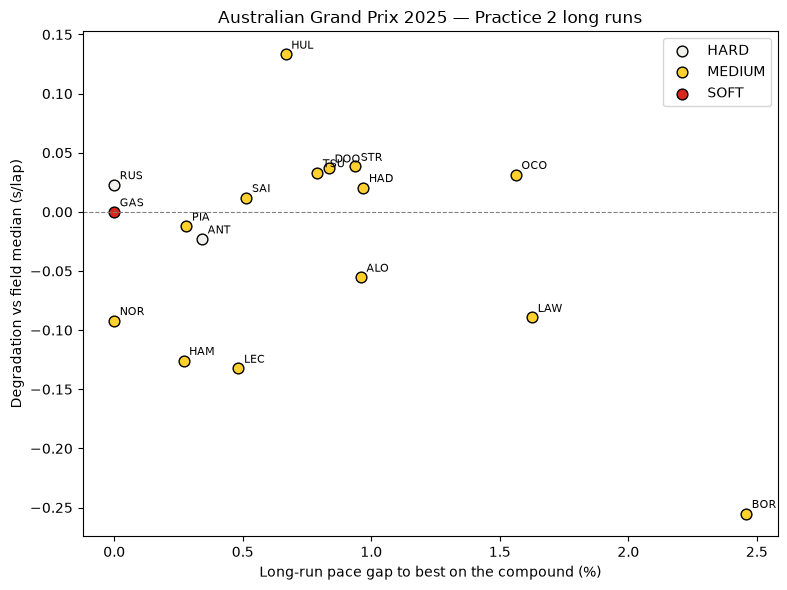

In [71]:
# Pace vs degradation: bottom-left is fast and easy on tyres
fig, ax = plt.subplots(figsize=(8, 6))
for compound, group in runs.groupby("Compound"):
    ax.scatter(group["pace_gap_pct"], group["deg_vs_field"], s=60, label=compound,
               color=f1plt.get_compound_color(compound, session=long_run_session), edgecolor="black")
    for _, run in group.iterrows():
        ax.annotate(run["Driver"], (run["pace_gap_pct"], run["deg_vs_field"]),
                    xytext=(4, 4), textcoords="offset points", fontsize=8)

ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.set_xlabel("Long-run pace gap to best on the compound (%)")
ax.set_ylabel("Degradation vs field median (s/lap)")
ax.set_title(f"{long_run_session.event['EventName']} {SEASON} — {long_run_session.name} long runs")
ax.legend()
plt.tight_layout()
plt.show()

## 13 · Weekend feature table

A prediction published at a stage may only use sessions that have already happened
(stage order in `docs/artifact-schema.md`). Race results are **labels** for this race
and only become features as history for later races.

`weekend_features()` joins each allowed session's by-driver features side by side, with
the session id as prefix (`fp2_best_lap_gap_pct`, `q_best_lap_rank`, ...). Joins use the
three-letter `Driver` code, because `DriverId` is empty for sprint qualifying.

The correlation below is from **one race**. It shows how the table is used, not which
features matter; that needs the backfill.

In [ ]:
# Sessions a prediction may use at each stage (docs/artifact-schema.md)
FEATURE_COLS = ["best_lap_gap_pct", "ideal_lap_gap_pct", "team_gap_pct", "best_lap_rank",
                "top_speed_rank", "laps_driven", "clean_lap_median", "clean_lap_std"]


def weekend_features(summaries, sessions):
    """one row per driver: FEATURE_COLS from each available session, prefixed with its id"""
    parts = [summaries[sid][0].set_index("Driver")[FEATURE_COLS].add_prefix(f"{sid.lower()}_")
             for sid in sessions if sid in summaries]
    return pd.concat(parts, axis=1)


event_format = weekend["R"].event["EventFormat"]
stage = "Q"
prev_stages = session_utils.get_session_stage(year=SEASON, rnd=RACE_ROUND, stage=stage)
features = weekend_features(summaries, prev_stages)

# qualifying position is known at stage Q; grid comes later (penalties are applied after Q)
features["q_position"] = weekend["Q"].results.set_index("Abbreviation")["Position"]
print(f"stage {stage}: {features.shape[0]} drivers x {features.shape[1]} features")
features.round(3).head()

stage Q: 20 drivers x 33 features


,fp1_best_lap_gap_pct,fp1_ideal_lap_gap_pct,fp1_team_gap_pct,fp1_best_lap_rank,fp1_top_speed_rank,fp1_laps_driven,fp1_clean_lap_median,fp1_clean_lap_std,fp2_best_lap_gap_pct,fp2_ideal_lap_gap_pct,fp2_team_gap_pct,fp2_best_lap_rank,fp2_top_speed_rank,fp2_laps_driven,fp2_clean_lap_median,fp2_clean_lap_std,fp3_best_lap_gap_pct,fp3_ideal_lap_gap_pct,fp3_team_gap_pct,fp3_best_lap_rank,fp3_top_speed_rank,fp3_laps_driven,fp3_clean_lap_median,fp3_clean_lap_std,q_best_lap_gap_pct,q_ideal_lap_gap_pct,q_team_gap_pct,q_best_lap_rank,q_top_speed_rank,q_laps_driven,q_clean_lap_median,q_clean_lap_std,q_position
Driver,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ALB,0.597,0.623,0.403,6.0,9.0,18,78.470,1.792,1.129,1.062,0.000,11.0,8.0,28,77.626,1.721,0.444,0.597,0.008,7.0,6.0,21,76.846,0.917,0.854,0.774,0.000,6.0,2.0,20,76.209,0.429,6.0
ALO,0.627,0.637,0.000,8.0,4.0,23,78.694,1.295,1.166,1.068,0.066,13.0,8.0,27,77.747,0.598,1.777,1.995,0.418,17.0,3.0,22,78.119,0.896,1.587,1.409,0.000,12.0,5.0,13,76.453,0.131,12.0
ANT,1.473,1.387,0.867,14.0,12.0,25,80.010,1.720,1.563,1.480,0.455,16.0,8.0,31,78.548,1.363,0.375,0.566,0.324,5.0,1.0,20,76.870,0.733,1.903,1.687,1.296,16.0,18.0,9,76.987,0.653,16.0
BEA,2.667,1.994,0.219,20.0,17.0,12,80.483,1.331,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,11.441,NaN,NaN,20.0,2,NaN,NaN,NaN,NaN,NaN,NaN,20.0,1,NaN,NaN,20.0
BOR,1.535,1.562,0.000,15.0,17.0,22,79.676,1.290,1.842,1.781,0.889,18.0,8.0,29,78.706,1.050,1.035,1.291,0.000,11.0,6.0,18,77.616,0.771,1.891,1.795,0.000,15.0,17.0,13,76.771,0.522,15.0


In [73]:
# Attach the label: race finishing position (Ergast), joined on the three-letter code
label = race_res.loc[race_res["round"] == RACE_ROUND].set_index("driverCode")["position"]
table = features.join(label.rename("race_position"))

corr = (table.corr(method="spearman")["race_position"]
             .drop("race_position").dropna().sort_values(key=abs, ascending=False))
print(f"Spearman correlation with race position, one race ({len(table)} drivers):")
corr.round(2).to_frame("rho").head(12)

Spearman correlation with race position, one race (20 drivers):


,rho
fp3_ideal_lap_gap_pct,0.62
fp2_clean_lap_std,-0.55
fp3_best_lap_gap_pct,0.51
fp3_best_lap_rank,0.51
q_position,0.49
q_clean_lap_median,0.46
q_ideal_lap_gap_pct,0.45
q_best_lap_rank,0.44
q_best_lap_gap_pct,0.44
fp1_clean_lap_std,-0.42


## 14 · Session timeline

`data_explore.session_timeline(session)` has one row per minute from start to finish:
weather, session status (running / red-flag aborted / finished), every track status active
in that minute, cars out on track, laps completed, and the race control messages issued
in that minute.

It is for charts with time on the x-axis. A circuit map needs position data instead; the
animated flag map that combines the two is in the backlog of `docs/pipeline-plan.md`.

Without telemetry, UTC `Date` (and so the message alignment) is anchored on the chequered
flag. That is within ~2 s of the telemetry anchor. The scheduled start was 3–18 min off for races.

→ feeds **比赛周天气** (observed), **安全车 / 红旗预测** (history) and **fun facts**.

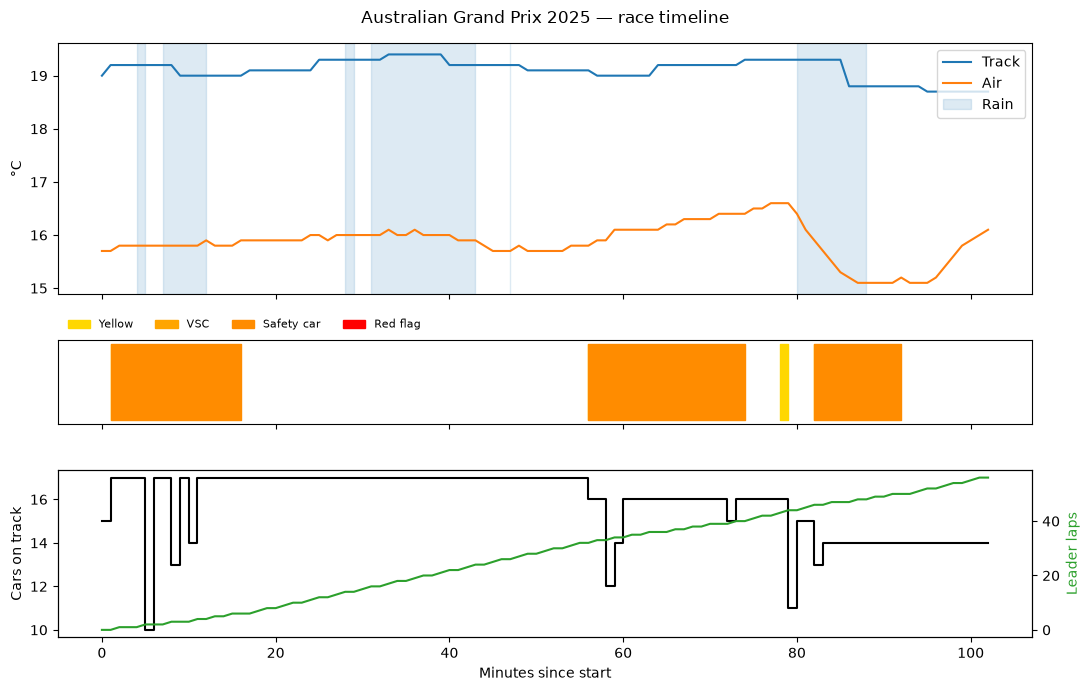

In [74]:
race_timeline = data_explore.session_timeline(weekend["R"])
minute = race_timeline["minute"]

FLAG_COLOURS = [("is_yellow", "gold", "Yellow"), ("is_vsc", "orange", "VSC"),
                ("is_sc", "darkorange", "Safety car"), ("is_red", "red", "Red flag")]

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1, 2]})

axes[0].plot(minute, race_timeline["TrackTemp"], label="Track")
axes[0].plot(minute, race_timeline["AirTemp"], label="Air")
axes[0].fill_between(minute, 0, 1, where=race_timeline["Rainfall"].astype(bool),
                     transform=axes[0].get_xaxis_transform(), color="tab:blue", alpha=0.15, label="Rain")
axes[0].set_ylabel("°C"); axes[0].legend(loc="upper right")

# flag band: later entries paint over earlier ones, so the most severe status wins
for col, colour, label in FLAG_COLOURS:
    axes[1].fill_between(minute, 0, 1, where=race_timeline[col], step="post", color=colour, label=label)
axes[1].set_yticks([])
axes[1].legend(loc="lower left", bbox_to_anchor=(0, 1), ncol=4, fontsize=8, frameon=False)

axes[2].plot(minute, race_timeline["cars_on_track"], drawstyle="steps-post", color="black")
axes[2].set_ylabel("Cars on track")
lap_axis = axes[2].twinx()
lap_axis.plot(minute, race_timeline["max_laps_completed"], color="tab:green")
lap_axis.set_ylabel("Leader laps", color="tab:green")
axes[2].set_xlabel("Minutes since start")

fig.suptitle(f"{weekend['R'].event['EventName']} {SEASON} — race timeline")
plt.tight_layout()
plt.show()

In [75]:
# Minutes with race control messages: the annotations for the chart above
race_timeline.loc[race_timeline["rc_n"] > 0, ["minute", "track_status", "max_laps_completed", "rc_messages"]].head(20)

,minute,track_status,max_laps_completed,rc_messages
0,0.0,1,0,GREEN LIGHT - PIT EXIT OPEN
1,1.0,124,0,DOUBLE YELLOW IN TRACK SECTOR 8 | SAFETY CAR D...
2,2.0,4,1,DOUBLE YELLOW IN TRACK SECTOR 20 | SAFETY CAR ...
6,6.0,4,2,RECOVERY VEHICLE ON TRACK AT TURN 14
7,7.0,4,2,RECOVERY VEHICLE ON TRACK BEFORE TURN 6
11,11.0,4,4,SAFETY CAR WILL USE START/FINISH STRAIGHT | CL...
12,12.0,4,4,CLEAR IN TRACK SECTOR 8
15,15.0,4,6,SAFETY CAR IN THIS LAP
16,16.0,14,6,TRACK CLEAR
17,17.0,1,6,INCIDENT INVOLVING CAR 14 (ALO) NOTED - SAFETY...
